<a href="https://colab.research.google.com/github/LCaravaggio/Happiness_Polarization/blob/main/Event_Studies_Pool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargar de datos

In [ ]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import re

BASE = "https://www.latinobarometro.org"
INDEX = f"{BASE}/agregados"

headers = {
    "User-Agent": "Mozilla/5.0"
}

# =========================
# 1. obtener páginas de cada ola
# =========================

html = requests.get(INDEX, headers=headers).text
soup = BeautifulSoup(html, "html.parser")

wave_pages = []

for a in soup.find_all("a", href=True):

    href = a["href"]

    # links tipo /latinobarometro-2023
    if re.search(r"latinobarometro-\d{4}$", href):

        full = urljoin(BASE, href)
        wave_pages.append(full)

wave_pages = sorted(set(wave_pages))

print("Olas encontradas:")
for w in wave_pages:
    print(w)

# =========================
# 2. entrar a cada ola y buscar ZIP de Stata
# =========================

stata_links = []

for page in wave_pages:

    print(f"\nRevisando {page}")

    try:
        html = requests.get(page, headers=headers, timeout=20).text
        soup = BeautifulSoup(html, "html.parser")

        for a in soup.find_all("a", href=True):

            href = a["href"]
            text = a.get_text(" ", strip=True).lower()

            full = urljoin(page, href)

            # queremos ZIPs relacionados con Stata
            if (
                ".zip" in href.lower()
                and (
                    "stata" in href.lower()
                    or "dta" in href.lower()
                    or "stata" in text
                )
            ):
                stata_links.append(full)

    except Exception as e:
        print("Error:", e)

# limpiar duplicados
stata_links = sorted(set(stata_links))

print("\nZIPs Stata encontrados:\n")

for l in stata_links:
    print(l)

Olas encontradas:
https://www.latinobarometro.org/latinobarometro-1995
https://www.latinobarometro.org/latinobarometro-1996
https://www.latinobarometro.org/latinobarometro-1997
https://www.latinobarometro.org/latinobarometro-1998
https://www.latinobarometro.org/latinobarometro-2000
https://www.latinobarometro.org/latinobarometro-2001
https://www.latinobarometro.org/latinobarometro-2002
https://www.latinobarometro.org/latinobarometro-2003
https://www.latinobarometro.org/latinobarometro-2004
https://www.latinobarometro.org/latinobarometro-2005
https://www.latinobarometro.org/latinobarometro-2006
https://www.latinobarometro.org/latinobarometro-2007
https://www.latinobarometro.org/latinobarometro-2008
https://www.latinobarometro.org/latinobarometro-2009
https://www.latinobarometro.org/latinobarometro-2010
https://www.latinobarometro.org/latinobarometro-2011
https://www.latinobarometro.org/latinobarometro-2013
https://www.latinobarometro.org/latinobarometro-2015
https://www.latinobarometro.

In [ ]:
import requests

import shutil
import os

# borrar carpeta rota
shutil.rmtree("latinobarometro", ignore_errors=True)

# recrear
os.makedirs("latinobarometro", exist_ok=True)

for link in stata_links:

    filename = link.split("/")[-1]
    filepath = os.path.join("latinobarometro", filename)

    print("Descargando:", filename)

    r = requests.get(link)

    with open(filepath, "wb") as f:
        f.write(r.content)

Descargando: latinobarometro-1995-dta.zip
Descargando: latinobarometro-1996-dta.zip
Descargando: latinobarometro-1997-dta.zip
Descargando: latinobarometro-1998-dta.zip
Descargando: latinobarometro-2000-dta.zip
Descargando: latinobarometro-2001-dta.zip
Descargando: latinobarometro-2002-dta.zip
Descargando: latinobarometro-2003-dta.zip
Descargando: latinobarometro-2004-dta.zip
Descargando: latinobarometro-2005-dta.zip
Descargando: latinobarometro-2006-dta.zip
Descargando: latinobarometro-2007-dta.zip
Descargando: latinobarometro-2008-dta.zip
Descargando: latinobarometro-2009-dta.zip
Descargando: latinobarometro-2010-dta.zip
Descargando: latinobarometro-2011-dta.zip
Descargando: latinobarometro-2013-dta.zip
Descargando: latinobarometro-2015-dta.zip
Descargando: latinobarometro2016-dta.zip
Descargando: latinobarometro2017-dta.zip
Descargando: latinobarometro-2018-eng-stata-v20190303.zip
Descargando: latinobarometro-2018-esp-dta-v20190303.zip
Descargando: latinobarometro-2020-eng-stata-v1-0

In [ ]:
!mkdir -p latinobarometro/unzipped

!find latinobarometro -name "*.zip" -exec unzip -o {} -d latinobarometro/unzipped \;

Archive:  latinobarometro/latinobarometro-2018-esp-dta-v20190303.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2018_Esp_Stata_v20190303.dta  
Archive:  latinobarometro/latinobarometro-1995-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_1995_Esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_1995_Eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_1995_datos_esp_v2014_06_27.dta  
  inflating: latinobarometro/unzipped/Latinobarometro_1995_data_english_v2014_06_27.dta  
Archive:  latinobarometro/latinobarometro-2006-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro_2006_eng.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2006_esp.pdf  
  inflating: latinobarometro/unzipped/Latinobarometro_2006_datos_eng_v2014_06_27.dta  
  inflating: latinobarometro/unzipped/Latinobarometro_2006_datos_esp_v2014_06_27.dta  
Archive:  latinobarometro/latinobarometro-2013-dta.zip
  inflating: latinobarometro/unzipped/Latinobarometro2

In [ ]:
# =========================
# mapeo armonizado
# =========================

varmap = {

    # ---------------------------------
    # satisfacción con la vida
    # ---------------------------------

    "life_satisfaction": {

        1997: "nsp10",
        2000: "P8ST",
        2001: "p41st",
        2002: "p1wvs",
        2003: "p19st",
        2004: "p1st",
        2005: "p1st",
        2006: "p1st_a",
        2007: "p1st",
        2008: "p27st",
        2009: "p1st",
        2010: "P1ST",
        2011: "P1ST",
        2013: "P1ST",
        2015: "P1ST",
        2016: "P1ST",
        2017: "P1ST",
        2018: "P1STC",
        2020: "p1st",
        2023: "P1ST",
        2024: "P1ST"
    },


    # ---------------------------------
    # situación económica actual del país
    # ---------------------------------

    "econ_country": {

        1995: "p1",
        1996: "p1",
        1997: "sp1",
        1998: "sp1",
        2000: "P1ST",
        2001: "p1st",
        2002: "p2sta",
        2003: "p1st",
        2004: "p2st",
        2005: "p2st",
        2006: "p2st",
        2007: "p100st",
        2008: "p4st",
        2009: "p3st_a",
        2010: "P3ST_A",
        2011: "P3ST_A",
        2013: "P3STGBS",
        2015: "P3STGBS",
        2016: "P4STGBS",
        2017: "P4STGBSC",
        2018: "P6STGBSC",
        2020: "p4stgbs",
        2023: "P5STGBS",
        2024: "P6STGBS"
    },

    # ---------------------------------
    # confianza interpersonal
    # ---------------------------------

    "trust_people": {

        1996: "p12",
        1997: "sp21",
        1998: "sp20",
        2000: "P17ST",
        2001: "p42st",
        2002: "p29st",
        2003: "p20st",
        2004: "p43st",
        2005: "p14st",
        2006: "p45st",
        2007: "p23st",
        2008: "p21wvsst",
        2009: "p58st",
        2010: "P55ST",
        2011: "P25ST",
        2013: "P29STGBS",
        2015: "P15STGBS",
        2016: "P12STGBS",
        2017: "P13STGBS",
        2018: "P11STGBS",
        2020: "p9stgbs",
        2023: "P9STGBS",
        2024: "P10STGBS"
    },

    # ---------------------------------
    # ciudad
    # ---------------------------------

    "city": {
        1997: "ciudad",
        2000: "ciudad",
        2001: "ciudad",
        2003: "ciudad",
        2004: "Ciudad",
        2005: "ciudad",
        2006: "ciudad",
        2007: "ciudad",
        2008: "ciudad",
        2009: "ciudad",
        2010: "ciudad",
        2011: "ciudad",
        2013: "ciudad",
        2015: "ciudad",
        2016: "ciudad",
        2017: "ciudad",
        2018: "CIUDAD",
        2020: "ciudad",
        2023: "ciudad",
        2024: "CIUDAD"
    },

    # ---------------------------------
    # interés en política
    # ---------------------------------

    "interest_politics": {

        1995: "p62",
        1996: "p64",
        1997: "sp41",
        1998: "sp36",
        2000: "P63ST",
        2001: "p56st",
        2003: "p61st",
        2004: "p29st",
        2005: "p37st",
        2007: "p59st",
        2009: "p32st",
        2010: "P23ST",
        2013: "P20STGBS",
        2020: "p46stgbs",
        2023: "P40STGBS",
        2024: "P36STGBS",

    },

    # ---------------------------------
    # sexo
    # ---------------------------------

    "sex": {

        1995: "s1",
        1996: "s1",
        1997: "s1",
        1998: "s1",
        2000: "S1",
        2001: "s1",
        2002: "s1",
        2003: "s1",
        2004: "s1",
        2005: "s6",
        2006: "s6",
        2007: "s10",
        2008: "s8",
        2009: "s5",
        2010: "S7",
        2011: "S16",
        2013: "S10",
        2015: "S12",
        2016: "sexo",
        2017: "sexo",
        2018: "SEXO",
        2020: "sexo",
        2023: "sexo",
        2024: "SEXO"
    },

    # ---------------------------------
    # edad
    # ---------------------------------

    "age": {

        1995: "s2",
        1996: "s2",
        1997: "s2",
        1998: "s2",
        2000: "S2",
        2001: "s2",
        2002: "s2",
        2003: "s2",
        2004: "s2",
        2005: "s7",
        2006: "s7",
        2007: "s11",
        2008: "s9",
        2009: "s6",
        2010: "S8",
        2011: "S17",
        2013: "S11",
        2015: "S13",
        2016: "edad",
        2017: "edad",
        2018: "EDAD",
        2020: "edad",
        2023: "edad",
        2024: "EDAD"
    },

    # ---------------------------------
    # estado civil
    # ---------------------------------

    "civil_status": {

        1995: "s6",
        1996: "s5",
        1997: "s5",
        1998: "s5",
        2000: "S4",
        2001: "s4",
        2002: "s4",
        2003: "s4",
        2004: "s4",
        2005: "s9",
        2006: "s9",
        2007: "s13",
        2008: "s3",
        2009: "s3",
        2010: "S5",
        2011: "S15",
        2013: "S9",
        2015: "S11",
        2016: "S5",
        2017: "S6",
        2018: "S23"
    },

    # ---------------------------------
    # izquierda-derecha
    # ---------------------------------

    "left_right": {

        1995: "p31",
        1996: "p38",
        1997: "sp56",
        1998: "sp52",
        2000: "P52ST",
        2001: "p54st",
        2002: "p64st",
        2003: "p60st",
        2004: "p87st",
        2005: "p34st",
        2006: "p47st",
        2007: "p67st",
        2008: "p56st",
        2009: "p69st",
        2010: "P60ST",
        2011: "P76ST",
        2013: "P41ST",
        2015: "P27ST",
        2016: "P17ST",
        2017: "P19STC",
        2018: "P22ST",
        2020: "p18st",
        2023: "P16ST",
        2024: "P16ST"
    },


    # ---------------------------------
    # país
    # ---------------------------------

    "country": {

        1995: "pais",
        1996: "pais",
        1997: "idenpa",
        1998: "idenpa",
        2000: "idenpa",
        2001: "idenpa",
        2002: "idenpa",
        2003: "idenpa",
        2004: "idenpa",
        2005: "idenpa",
        2006: "idenpa",
        2007: "idenpa",
        2008: "idenpa",
        2009: "idenpa",
        2010: "idenpa",
        2011: "idenpa",
        2013: "idenpa",
        2015: "idenpa",
        2016: "idenpa",
        2017: "idenpa",
        2018: "IDENPA",
        2020: "idenpa",
        2023: "idenpa",
        2024: "IDENPA"
    },

    # ---------------------------------
    # educación
    # ---------------------------------

"education": {

    1995: "s17",
    1996: "s14",
    1997: "s10",
    1998: "s11",
    2000: "S6",
    2001: "s6",
    2002: "s6",
    2003: "s6",
    2004: "s6",
    2005: "s11",
    2006: "s11",
    2007: "s15",
    2008: "s15",
    2009: "s12",
    2010: "S14",
    2011: "S21",
    2013: "S17",
    2015: "S19",
    2016: "S13",
    2017: "S14",
    2018: "S10",
    2020: "s16",
    2023: "S11",
    2024: "S11"
},

# ---------------------------------
# twitter
# ---------------------------------

"twitter": {

    2009: "S25_E",
    2010: "S27_E",
    2011: "S33ST_BE",
    2013: "P83TNCE",
    2015: "S10M_E",
    2016: "S15M_D",
    2017: "S16M_D",
    2018: "S12M.D",
    2020: "s19m_04",
    2023: "S14M_D",
    2024: "S14M.4"

},

# ---------------------------------
# Voto
# ---------------------------------
"vote": {

    1995: "p33",
    1996: "p40",
    1997: "sp58",
    1998: "sp53",
    2000: "P54ST",
    2001: "p55st",
    2002: "p45st",
    2003: "p54st",
    2004: "p30st",
    2005: "p48st",
    2006: "p38st",
    2007: "p64st",
    2008: "p61st",
    2009: "p35st",
    2010: "P29ST",
    2011: "P38ST",
    2013: "P22TGBSM",
    2015: "P23TGBSM",
    2016: "P15STGBS",
    2017: "P16STGBS",
    2018: "P21STGBS.A",
    2020: "P50STGBS_A",
    2023: "P43STGBS_A",
    2024: "P39STGBS.A"
},

# ---------------------------------
# Confianza en el Congreso
# ---------------------------------

"confianza_congreso": {
    1995: "p27i",
    1996: "p33i",
    1997: "sp63f",
    1998: "sp38f",
    2000: "P35ST_F",
    2001: "p61stf",
    2002: "p36std",
    2003: "p21stf",
    2004: "p34stf",
    2005: "p45sta",
    2006: "p24st_f",
    2007: "p24st_f",
    2008: "p28st_a",
    2009: "p26st_a",
    2010: "P20ST_A",
    2011: "P22ST_A",
    2013: "P26TGB_C",
    2015: "P16ST_F",
    2016: "P13STD",
    2017: "P14ST_D",
    2018: "P15STGBSC.D",
    2020: "p13st_d",
    2023: "P13ST_D",
    2024: "P14ST.D"
},

# ---------------------------------
# Confianza en el Gobierno
# ---------------------------------

"confianza_gobierno": {
    1995: "p27m",
    1996: "p33m",
    2002: "p34std",
    2003: "p23stg",
    2004: "p32std",
    2005: "p45stc",
    2006: "p32st_a",
    2007: "p24st_a",
    2008: "p31s_ta",
    2009: "p24st_a",
    2010: "P18ST_A",
    2011: "P20ST_A",
    2013: "P26TGB_B",
    2015: "P16ST_G",
    2016: "P13STE",
    2017: "P14ST_E",
    2018: "P15STGBSC.E",
    2020: "p13st_e",
    2023: "P13ST_E",
    2024: "P14ST.E"
},

# ---------------------------------
# Confianza en el Poder Judicial
# ---------------------------------

"confianza_judicial": {
    1995: "p27d",
    1996: "p33d",
    1997: "sp63c",
    1998: "sp38c",
    2000: "P35ST_C",
    2001: "p61stc",
    2002: "p34stc",
    2003: "p21ste",
    2004: "p34stb",
    2005: "p42std",
    2006: "p24st_a",
    2007: "p24st_d",
    2008: "p28st_b",
    2009: "p26st_b",
    2010: "P20ST_B",
    2011: "P22ST_B",
    2013: "P26TGB_E",
    2015: "P16ST_H",
    2016: "P13STF",
    2017: "P14ST_F",
    2018: "P15STGBSC.F",
    2020: "p13st_f",
    2023: "P13ST_F",
    2024: "P14ST.F"
},

# ---------------------------------
# Día
# ---------------------------------

"dia_real": {
    1997: "diareal",
    1998: "diareal",
    2000: "diareal",
    2001: "diareal",
    2002: "diareal",
    2003: "diareal",
    2004: "diareal",
    2005: "diareal",
    2006: "diareal",
    2007: "diareal",
    2008: "diareal",
    2009: "diareal",
    2010: "diareal",
    2011: "diareal",
    2013: "diareal",
    2015: "diareal",
    2016: "diareal",
    2017: "diareal",
    2018: "DIAREAL",
    2020: "diareal",
    2023: "diareal",
    2024: "DIAREAL",
},


# ---------------------------------
# Mes
# ---------------------------------

"mes_real": {
    1997: "mesreal",
    1998: "mesreal",
    2000: "mesreal",
    2001: "mesreal",
    2002: "mesreal",
    2003: "mesreal",
    2004: "mesreal",
    2005: "mesreal",
    2006: "mesreal",
    2007: "mesreal",
    2008: "mesreal",
    2009: "mesreal",
    2010: "mesreal",
    2011: "mesreal",
    2013: "mesreal",
    2015: "mesreal",
    2016: "mesreal",
    2017: "mesreal",
    2018: "MESREAL",
    2020: "mesreal",
    2023: "mesreal",
    2024: "MESREAL",
}


}

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path("latinobarometro/unzipped")

# =========================
# buscar archivos
# =========================

dta_files = sorted([
    f for f in BASE.rglob("*.dta")
    if "eng" not in f.name.lower()
])

# =========================
# detectar ola
# =========================

def detect_wave(path):

    m = re.search(r"(19|20)\d{2}", path.name)

    if m:
        return int(m.group())

    return np.nan

# =========================
# verificar SOLO faltantes
# =========================

for file in dta_files:

    try:

        wave = detect_wave(file)

        # leer pocas filas
        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        existing_cols = set(tmp.columns)

        missing = []

        # -------------------------
        # revisar varmap
        # -------------------------

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var not in existing_cols:

                missing.append(
                    f"{new_name} -> {old_var}"
                )

        # -------------------------
        # imprimir sólo si faltan
        # -------------------------

        if len(missing) > 0:

            print("\n" + "="*60)
            print(f"{file.name} | wave={wave}")

            for m in missing:
                print("FALTA:", m)

        del tmp
        del tmp_reader

    except Exception as e:

        print(f"\nERROR en {file.name}")
        print(e)

In [ ]:
def detect_id(df):

    for c in [
        "IDNUM",
        "idnum",
        "Idnum",
        "id_num",
        "NUMINVES",
        "numinves",
        "folio",
        "FOLIO",
        "numero",
        "NUMERO"
    ]:

        if c in df.columns:
            return c

    return None

# =========================
# merge final
# =========================

master = pd.DataFrame()

for file in dta_files:

    try:

        wave = detect_wave(file)

        print(f"Cargando {file.name} | wave={wave}")

        # -------------------------
        # leer nombres columnas
        # -------------------------

        tmp_reader = pd.read_stata(
            file,
            convert_categoricals=False,
            iterator=True
        )

        tmp = tmp_reader.read(5)

        # normalizar nombres
        tmp.columns = (
            tmp.columns
            .str.strip()
        )

        existing_cols = set(tmp.columns)

        # -------------------------
        # detectar ID
        # -------------------------

        id_col = detect_id(tmp)

        if id_col is None:

            print("  -> no se encontró ID")
            continue

        # -------------------------
        # variables disponibles
        # -------------------------

        wave_vars = {}

        for new_name, mapping in varmap.items():

            if wave not in mapping:
                continue

            old_var = mapping[wave]

            if old_var in existing_cols:

                wave_vars[new_name] = old_var

        # columnas a leer
        cols_to_read = list(
            set(wave_vars.values()) | {id_col}
        )

        # -------------------------
        # cargar datos reales
        # -------------------------

        df = pd.read_stata(
            file,
            columns=cols_to_read,
            convert_categoricals=False
        )

        # normalizar columnas
        df.columns = (
            df.columns
            .str.strip()
        )

        # -------------------------
        # crear ID
        # -------------------------

        df["id"] = df[id_col].astype(str)

        # -------------------------
        # renombrar variables
        # -------------------------

        rename_dict = {
            old: new
            for new, old in wave_vars.items()
        }

        df = df.rename(columns=rename_dict)

        # -------------------------
        # agregar ola
        # -------------------------

        df["wave"] = wave

        # -------------------------
        # conservar columnas finales
        # -------------------------

        keep_cols = [
            "id",
            "wave",
            "dia_real",
            "mes_real",
            "country",
            "city",
            "life_satisfaction",
            "interest_politics",
            "sex",
            "age",
            "civil_status",
            "left_right",
            "education",
            "econ_country",
            "trust_people",
            "twitter",
            "vote",
            "confianza_congreso",
            "confianza_gobierno",
            "confianza_judicial"
        ]

        # crear faltantes
        for c in keep_cols:

            if c not in df.columns:
                df[c] = np.nan

        df = df[keep_cols]

        # -------------------------
        # append
        # -------------------------

        master = pd.concat(
            [master, df],
            ignore_index=True,
            sort=False
        )

        del df
        del tmp
        del tmp_reader

    except Exception as e:

        print(f"ERROR en {file.name}")
        print(e)

Cargando Latinobarometro2013.dta | wave=2013
Cargando Latinobarometro2016Esp_v20170205.dta | wave=2016
Cargando Latinobarometro2017Esp_v20180117.dta | wave=2017
Cargando Latinobarometro_1995_datos_esp_v2014_06_27.dta | wave=1995
Cargando Latinobarometro_1996_datos_esp_v2014_06_27.dta | wave=1996
Cargando Latinobarometro_1997_datos_esp_v2014_06_27.dta | wave=1997
Cargando Latinobarometro_1998_datos_esp_v2014_06_27.dta | wave=1998
Cargando Latinobarometro_2000_datos_esp_v2014_06_27.dta | wave=2000
Cargando Latinobarometro_2001_datos_esp_v2014_06_27.dta | wave=2001
Cargando Latinobarometro_2002_datos_esp_v2014_06_27.dta | wave=2002
Cargando Latinobarometro_2003_datos_esp_v2014_06_27.dta | wave=2003
Cargando Latinobarometro_2004_datos_esp_v2014_06_27.dta | wave=2004
Cargando Latinobarometro_2005_datos_esp_v2014_06_27.dta | wave=2005
Cargando Latinobarometro_2006_datos_esp_v2014_06_27.dta | wave=2006
Cargando Latinobarometro_2007_datos_esp_v2014_06_27.dta | wave=2007
Cargando Latinobarometr

# Recodificación

In [ ]:
# =========================
# recodificar life_satisfaction
# =========================

conversion = {

    4: 1,  # para nada
    3: 2,  # no muy
    2: 3,  # bastante
    1: 4   # muy
}

master["life_satisfaction"] = (
    master["life_satisfaction"]
    .map(conversion)
)

# =========================
# recodificar interest_politics
# =========================

master["interest_politics"] = (
    master["interest_politics"]
    .replace(conversion)
)

# =========================
# recodificar sex
# =========================

conversion = {
    1: 1,  # hombre
    2: 0   # mujer
}

master["sex"] = (
    master["sex"]
    .map(conversion)
)

# =========================
# distancia al centro ideológico
# =========================

def convertir(val):

    try:

        num = float(val)

        # missings típicos latinobarómetro
        if num in [97, 98, 99, -1, -2, -6, -8]:
            return np.nan

        return num

    except:

        return np.nan

# convertir escala izquierda-derecha
master["left_right_scale"] = (
    master["left_right"]
    .apply(convertir)
)

# distancia al centro
master["left_right_distance"] = (
    np.abs(master["left_right_scale"] - 5)
)

master["polarization"]=master["left_right_distance"]

# =========================
# recodificar education
# =========================

# paso 1
master["education_num"] = pd.to_numeric(
    master["education"],
    errors="coerce"
)

# paso 2
def escalar_educacion(x):

    if pd.isna(x):
        return np.nan

    if x == 1:
        return 0  # sin estudios

    elif 2 <= x <= 13:
        return x - 1  # años reales

    elif x == 14:
        return 14  # universitario incompleto

    elif x == 15:
        return 16  # universitario completo

    elif x == 16:
        return 13  # técnico incompleto

    elif x == 17:
        return 14  # técnico completo

    else:
        return np.nan

# aplicar
master["education"] = (
    master["education_num"]
    .apply(escalar_educacion)
)


# =========================
# recodificar econ_country
# =========================

master["econ_country"] = pd.to_numeric(
    master["econ_country"],
    errors="coerce"
)

conversion_econ = {

    1: 5,  # muy buena
    2: 4,  # buena
    3: 3,  # regular
    4: 2,  # mala
    5: 1   # muy mala
}

master["econ_country"] = (
    master["econ_country"]
    .map(conversion_econ)
)

# =========================
# recodificar trust_people
# =========================

conversion = {

    1: 1,  # se puede confiar
    2: 0   # nunca suficientemente cuidadoso
}

master["trust_people"] = pd.to_numeric(
    master["trust_people"],
    errors="coerce"
)

master["trust_people"] = (
    master["trust_people"]
    .map(conversion)
)

# cualquier valor no mapeado -> NaN
master.loc[
    ~master["trust_people"].isin([0, 1]),
    "trust_people"
] = np.nan

master["twitter"] = np.where(
    master["twitter"] == 1,
    1,
    np.where(
        master["twitter"] == 0,
        0,
        np.nan
    )
)

sin_partido = {
    -7, -4, -3, -2, -1,
    94, 95, 96, 97
}

master["party_id"] = (
    (~master["vote"].isin(sin_partido))
    & (master["vote"].notna())
).astype(int)


conversion_confianza = {
    4: 1,  # ninguna
    3: 2,  # poca
    2: 3,  # algo
    1: 4   # mucha confianza
}

master["confianza_congreso"] = (
    master["confianza_congreso"]
    .map(conversion_confianza)
)

master["confianza_gobierno"] = (
    master["confianza_gobierno"]
    .map(conversion_confianza)
)

master["confianza_judicial"] = (
    master["confianza_judicial"]
    .map(conversion_confianza)
)

In [ ]:
master["interest_politics"] = master["interest_politics"].replace(-2, np.nan)
master["interest_politics"] = master["interest_politics"].replace(-1, np.nan)


master["age"] = master["age"].replace(-2, np.nan)

master["civil_status"] = master["civil_status"].replace(-2, np.nan)

master["left_right"] = master["left_right"].replace(
    [-8, 97],
    np.nan
)

master["vote"] = master["vote"].replace(
    [-7, -1],
    np.nan
)

# Confianza institucional es el promedio de congreso, gobierno y judicial.
master["confianza_institucional"] = (
    master[
        [
            "confianza_congreso",
            "confianza_gobierno",
            "confianza_judicial"
        ]
    ].mean(axis=1)
)

In [ ]:
#Eliminamos España
master = master[master['country'] != 724]

In [ ]:
vars_z = [
     "life_satisfaction",
     "interest_politics",
     "education" ,
     "econ_country",
     "confianza_institucional",
     "polarizacion_ind",
     "democracia_vdem"
    ]

for v in vars_z:
    master[f"{v}_z"] = np.nan

for wave in master["wave"].unique():
    mask = master["wave"] == wave
    for v in vars_z:
        if v in master.columns:
            s = master.loc[mask, v].astype(float)
            mean = s.mean(skipna=True)
            sd = s.std(skipna=True)
            master.loc[mask, f"{v}_z"] = (s - mean) / sd if sd not in [0, None] else np.nan

# Identificación

In [ ]:
import pandas as pd

# Crear fecha completa de la encuesta
master['fecha_encuesta'] = pd.to_datetime(
    dict(
        year=pd.to_numeric(master['wave'], errors='coerce'),
        month=pd.to_numeric(master['mes_real'], errors='coerce'),
        day=pd.to_numeric(master['dia_real'], errors='coerce')
    ),
    errors='coerce'
)

# Fecha de inicio y fin de cada ola en cada país
fechas_encuestas = (
    master
    .groupby(['country', 'wave'], as_index=False)
    .agg(
        fecha_inicio=('fecha_encuesta', 'min'),
        fecha_fin=('fecha_encuesta', 'max'),
        n_obs=('fecha_encuesta', 'count')
    )
    .sort_values(['country', 'wave'])
)

In [ ]:
import pandas as pd

eventos_en_ola = pd.DataFrame([
    {'country': 'Brazil', 'country_id': 76, 'event_date': '17/06/2013'},
    {'country': 'Colombia', 'country_id': 170, 'event_date': '17/06/2018'},
    {'country': 'Peru', 'country_id': 604, 'event_date': '05/06/2016'},
    {'country': 'Venezuela', 'country_id': 862, 'event_date': '03/06/2004'},
   # {'country': 'Brazil', 'country_id': 76, 'event_date': '29/10/2006'},
   # {'country': 'Ecuador', 'country_id': 218, 'event_date': '15/10/2006'},
   # {'country': 'Ecuador', 'country_id': 218, 'event_date': '28/09/2008'},
   # {'country': 'Venezuela', 'country_id': 862, 'event_date': '26/09/2010'},
   # {'country': 'Venezuela', 'country_id': 862, 'event_date': '06/12/2020'},
    {'country': 'Bolivia', 'country_id': 68, 'event_date': '11/09/2008'},
    {'country': 'Costa Rica', 'country_id': 188, 'event_date': '05/10/2020'},
    {'country': 'Guatemala', 'country_id': 320, 'event_date': '24/07/2003'},
    {'country': 'Guatemala', 'country_id': 320, 'event_date': '21/11/2020'},
    {'country': 'Peru', 'country_id': 604, 'event_date': '10/11/2020'},
    {'country': 'Venezuela', 'country_id': 862, 'event_date': '30/07/2017'},
    {'country': 'Mexico', 'country_id': 484, 'event_date': '26/02/2023'},
    {'country': 'Chile', 'country_id': 152, 'event_date': '08/03/2023'},
    {'country': 'Uruguay', 'country_id': 858, 'event_date': '08/03/2023'}
])

eventos_en_ola['event_day'] = pd.to_datetime(
    eventos_en_ola['event_date'],
    format='%d/%m/%Y'
)

eventos_en_ola['wave'] = eventos_en_ola['event_day'].dt.year

eventos_en_ola['event_date'] = pd.to_datetime(
    eventos_en_ola['event_date'],
    format='%d/%m/%Y'
)

# Event Study

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ============================================================
# VARIABLES
# ============================================================

variables = [
    'life_satisfaction',
    'interest_politics',
    'econ_country',
    'trust_people',
    'left_right_distance',
    'confianza_institucional'
]

# ============================================================
# PARÁMETROS
# ============================================================

DIA_MIN = -8
DIA_MAX = 8
DIA_REFERENCIA = -1

# ============================================================
# MASTER: CONSTRUIR FECHA DE ENTREVISTA
# ============================================================

master_es = master.copy()

# Convertir componentes de fecha a numéricos
for col in ['wave', 'mes_real', 'dia_real', 'country']:
    master_es[col] = pd.to_numeric(
        master_es[col],
        errors='coerce'
    )

# Construir fecha de entrevista
master_es['fecha_entrevista'] = pd.to_datetime(
    {
        'year': master_es['wave'],
        'month': master_es['mes_real'],
        'day': master_es['dia_real']
    },
    errors='coerce'
)

# ============================================================
# EVENTOS: NORMALIZAR TIPOS
# ============================================================

eventos_en_ola = eventos_en_ola.copy()

eventos_en_ola['country_id'] = pd.to_numeric(
    eventos_en_ola['country_id'],
    errors='coerce'
)

eventos_en_ola['wave'] = pd.to_numeric(
    eventos_en_ola['wave'],
    errors='coerce'
)

# Usar event_date como fecha del evento
eventos_en_ola['event_date'] = pd.to_datetime(
    eventos_en_ola['event_date'],
    errors='coerce'
)

# Eliminar eventos sin identificadores o fechas válidas
eventos_en_ola = eventos_en_ola.dropna(
    subset=['country_id', 'wave', 'event_date']
).copy()

eventos_en_ola['country_id'] = (
    eventos_en_ola['country_id'].astype(int)
)

eventos_en_ola['wave'] = (
    eventos_en_ola['wave'].astype(int)
)

# ============================================================
# CONSTRUIR BASE POOLED DE EVENTOS
# ============================================================

observaciones_eventos = []

for i, evento in eventos_en_ola.iterrows():

    country = int(evento['country_id'])
    wave = int(evento['wave'])
    fecha_evento = pd.Timestamp(evento['event_date'])

    # Muestra país × ola
    es = master_es[
        (master_es['country'] == country) &
        (master_es['wave'] == wave)
    ].copy()

    if es.empty:
        print(
            f"Sin observaciones: {evento['country']} "
            f"{fecha_evento.date()}"
        )
        continue

    # Eliminar entrevistas sin fecha válida
    es = es.dropna(
        subset=['fecha_entrevista']
    ).copy()

    # Diferencia en días enteros
    es['dias_evento'] = (
        es['fecha_entrevista'] - fecha_evento
    ).dt.days

    es = es.dropna(
        subset=['dias_evento']
    ).copy()

    es['dias_evento'] = es['dias_evento'].astype('int64')

    # Aplicar ventana
    es = es[
        es['dias_evento'].between(DIA_MIN, DIA_MAX)
    ].copy()

    if es.empty:
        print(
            f"Sin entrevistas en la ventana: "
            f"{evento['country']} {fecha_evento.date()}"
        )
        continue

    # Identificación del evento
    es['event_day'] = fecha_evento
    es['event_id'] = i

    observaciones_eventos.append(es)

# ============================================================
# UNIFICAR EVENTOS
# ============================================================

if not observaciones_eventos:
    raise ValueError(
        "No hay observaciones dentro de las ventanas de los eventos. "
        "Revisá países, olas y fechas."
    )

eventos_pooled = pd.concat(
    observaciones_eventos,
    ignore_index=True
)

eventos_pooled['dias_evento'] = (
    eventos_pooled['dias_evento'].astype('int64')
)

print("Observaciones pooled:", len(eventos_pooled))
print("Días observados:", sorted(
    eventos_pooled['dias_evento'].unique()
))

# ============================================================
# EVENT STUDIES POOLED
# ============================================================

todos_resultados = []
todos_modelos = {}

for variable in variables:

    if variable not in eventos_pooled.columns:
        print(f"No existe la variable: {variable}")
        continue

    data = eventos_pooled.dropna(
        subset=[variable, 'dias_evento']
    ).copy()

    if data.empty:
        print(f"Sin observaciones válidas para {variable}")
        continue

    # Asegurar tipos numéricos
    data[variable] = pd.to_numeric(
        data[variable],
        errors='coerce'
    )

    data['dias_evento'] = pd.to_numeric(
        data['dias_evento'],
        errors='coerce'
    )

    data = data.dropna(
        subset=[variable, 'dias_evento']
    ).copy()

    if data.empty:
        continue

    data['dias_evento'] = (
        data['dias_evento'].round().astype('int64')
    )

    # Verificar la categoría de referencia
    dias_observados = set(data['dias_evento'].unique())

    if DIA_REFERENCIA not in dias_observados:
        print(
            f"No existe día {DIA_REFERENCIA} "
            f"para {variable}. "
            f"Días disponibles: {sorted(dias_observados)}"
        )
        continue

    # --------------------------------------------------------
    # DUMMIES DE DÍAS
    # --------------------------------------------------------

    X = pd.get_dummies(
        data['dias_evento'],
        prefix='dia',
        dtype=float
    )

    # Normalizar nombres para asegurar formato dia_-1, dia_0...
    X.columns = [
        f'dia_{int(col.replace("dia_", ""))}'
        for col in X.columns
    ]

    nombre_ref = f'dia_{DIA_REFERENCIA}'

    if nombre_ref not in X.columns:
        print(
            f"Error en dummies para {variable}. "
            f"Columnas: {X.columns.tolist()}"
        )
        continue

    # Día -1 como referencia
    X = X.drop(columns=[nombre_ref])

    X = sm.add_constant(X, has_constant='add')

    # Asegurar que X e Y sean numéricos
    X = X.astype(float)
    y = data[variable].astype(float)

    # --------------------------------------------------------
    # OLS
    # --------------------------------------------------------

    modelo = sm.OLS(
        y,
        X
    ).fit(
        cov_type='HC1'
    )

    # --------------------------------------------------------
    # RESULTADOS
    # --------------------------------------------------------

    resultados = []

    for dia in range(DIA_MIN, DIA_MAX + 1):

        if dia == DIA_REFERENCIA:
            beta = 0.0
            se = 0.0

        else:
            nombre = f'dia_{dia}'

            if nombre in modelo.params.index:
                beta = modelo.params[nombre]
                se = modelo.bse[nombre]
            else:
                beta = np.nan
                se = np.nan

        resultados.append({
            'dia': dia,
            'beta': beta,
            'se': se
        })

    r = pd.DataFrame(resultados)

    r['ci_low'] = r['beta'] - 1.96 * r['se']
    r['ci_high'] = r['beta'] + 1.96 * r['se']
    r['variable'] = variable
    r['n'] = len(data)

    todos_resultados.append(r)
    todos_modelos[variable] = modelo

# ============================================================
# RESULTADO FINAL
# ============================================================

if not todos_resultados:
    raise ValueError(
        "No se estimó ningún modelo. Revisá los mensajes "
        "de diagnóstico anteriores."
    )

resultados_event_study = (
    pd.concat(todos_resultados, ignore_index=True)
    [
        [
            'variable',
            'dia',
            'beta',
            'se',
            'ci_low',
            'ci_high',
            'n'
        ]
    ]
    .sort_values(['variable', 'dia'])
    .reset_index(drop=True)
)


Observaciones pooled: 8093
Días observados: [np.int64(-8), np.int64(-7), np.int64(-6), np.int64(-5), np.int64(-4), np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


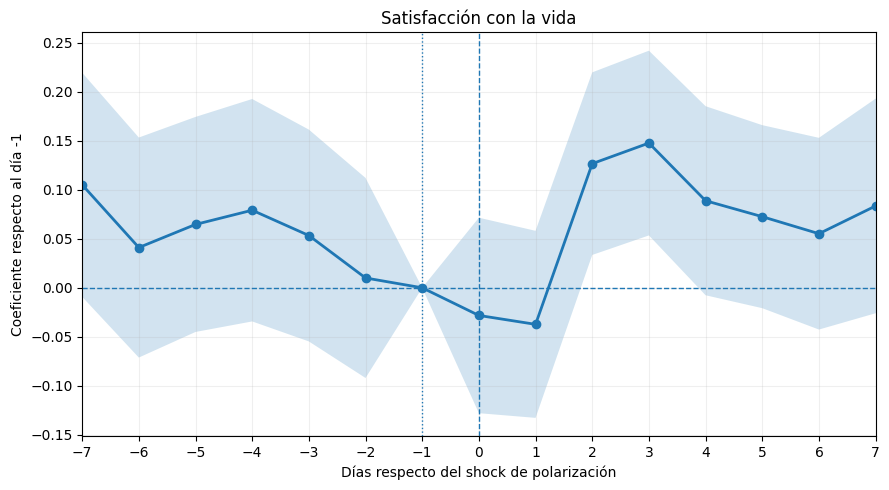

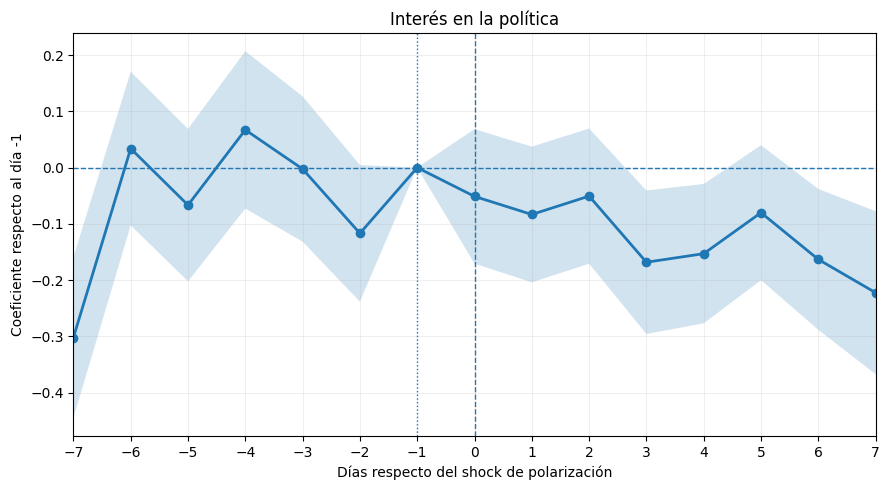

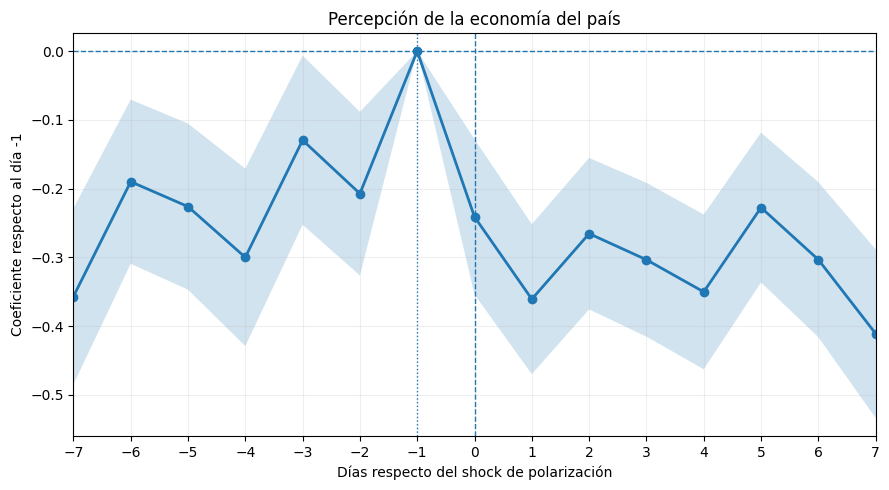

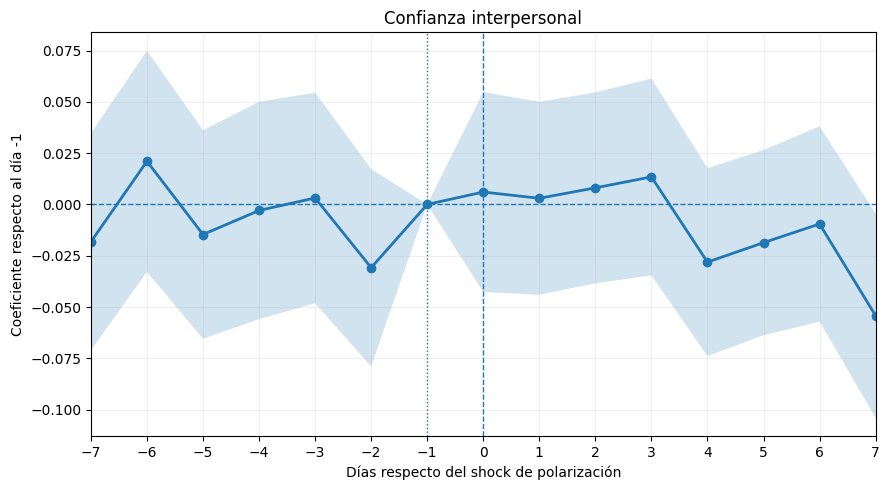

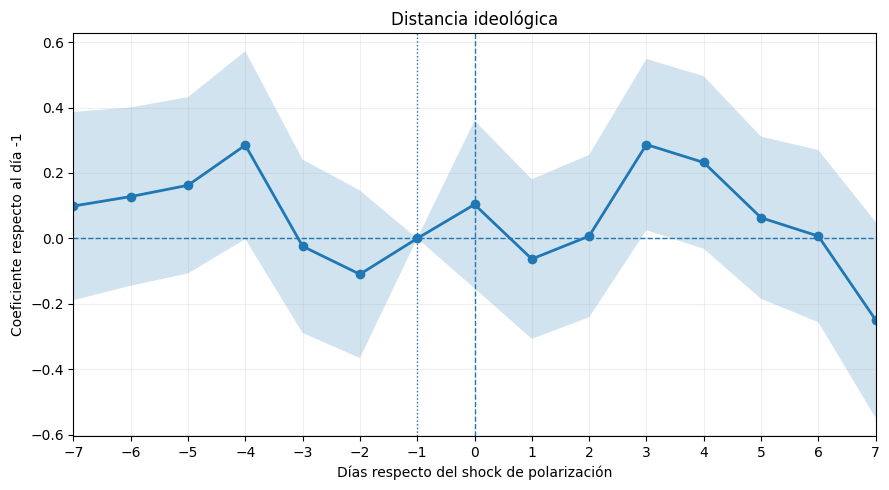

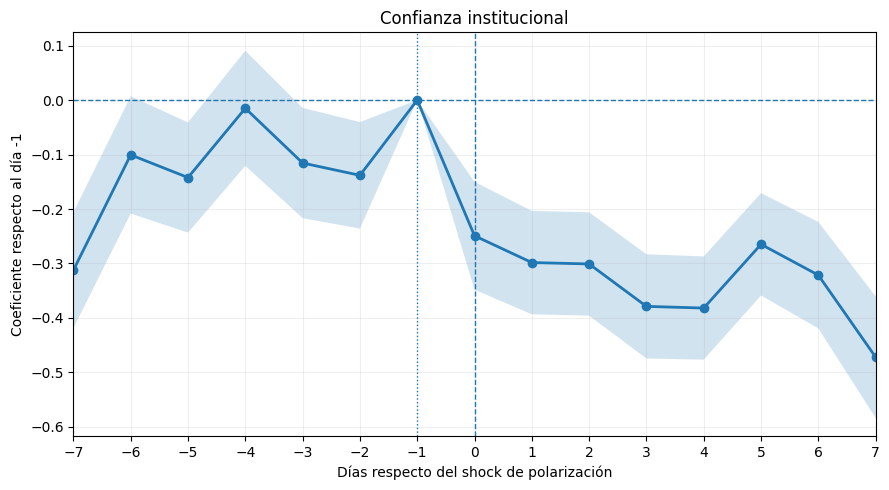

In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# GRÁFICOS DE TODAS LAS VARIABLES
# ============================================================

variables = [
    'life_satisfaction',
    'interest_politics',
    'econ_country',
    'trust_people',
    'left_right_distance',
    'confianza_institucional'
]

titulos = {
    'life_satisfaction': 'Satisfacción con la vida',
    'interest_politics': 'Interés en la política',
    'econ_country': 'Percepción de la economía del país',
    'trust_people': 'Confianza interpersonal',
    'left_right_distance': 'Distancia ideológica',
    'confianza_institucional': 'Confianza institucional'
}

for variable in variables:

    r = resultados_event_study[
        resultados_event_study['variable'] == variable
    ].copy()

    if len(r) == 0:
        continue

    plt.figure(figsize=(9, 5))

    # Intervalo de confianza
    plt.fill_between(
        r['dia'],
        r['ci_low'],
        r['ci_high'],
        alpha=0.20
    )

    # Coeficientes
    plt.plot(
        r['dia'],
        r['beta'],
        marker='o',
        linewidth=2
    )

    # Línea horizontal en cero
    plt.axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    # Línea vertical en el día del shock
    plt.axvline(
        0,
        linestyle='--',
        linewidth=1
    )

    # Línea del período de referencia
    plt.axvline(
        -1,
        linestyle=':',
        linewidth=1
    )

    plt.title(
        titulos.get(variable, variable)
    )

    plt.xlabel(
        'Días respecto del shock de polarización'
    )

    plt.ylabel(
        'Coeficiente respecto al día -1'
    )

    plt.xticks(
        range(-7, 8)
    )

    plt.xlim(
        -7,
        7
    )

    plt.grid(
        alpha=0.2
    )

    plt.tight_layout()

    plt.show()